<a href="https://colab.research.google.com/github/varun-122/Disney-EDA/blob/main/Copy_of_Disney%2B_Explanatory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disney+ Dataset – Exploratory Data Analysis
**Name:** Varun Sharma  
**Course:** Data Science  
**Date:** 14 June 2025


## 1. Introduction

The dataset titled “Disney+ Movies and TV Shows” contains information about titles available on the Disney+ streaming platform as of 2021. It includes metadata for each title such as:

Title: Name of the show or movie

Type: Movie or TV Show

Director and Cast

Country of production

Date Added to Disney+

Release Year

Rating, Duration, and Genres

**Project Goals**

The primary goal of this EDA (Exploratory Data Analysis) is to:

Understand the composition of Disney+ content in terms of type, genre, release year, and rating.

Analyze trends over time, such as how many titles are added each year.

Identify content patterns, such as popular genres, countries, or durations.

Create visualizations to uncover hidden insights and support storytelling.

Clean and transform the data to make it analysis-ready using pandas.

By the end of this EDA, we aim to gain actionable insights about Disney+ content strategy, target audience, and historical trends.


## 2. Data Overview
- `.shape`
- `.info()`
- `.describe()`
- Sample records using `df.head()`

## 3. Data Cleaning
- Handling missing values
- Date parsing
- Removing duplicates (if any)

## 4. Feature Engineering
- Extracting `year_added`, `month_added`
- Creating new columns like content age, type flags, etc.

## 5. Univariate Analysis
- Countplots, value_counts for:
  - Type (Movie vs TV Show)
  - Rating
  - Release year
  - Country

## 6. Bivariate/Multivariate Analysis
- Year vs number of titles added
- Type vs rating
- Genre vs type

## 7. Visualizations
- Use `seaborn`, `matplotlib`, or `plotly`
- Bar charts, pie charts, line plots

## 8. Key Findings
Summarize what insights you found:
- Is Disney+ adding more movies or shows recently?
- Which ratings are most common?
- Popular countries or genres?

## 9. Conclusion
- Final thoughts
- Limitations
- Scope for further analysis

## 10. References
- Kaggle dataset link
- Google Drive share link

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
!pip install -q gdown
!gdown 1sbEscBFgMh9KjGQdPcl6HnEp5MdxrTwY --output disney_plus_titles.csv


Downloading...
From: https://drive.google.com/uc?id=1sbEscBFgMh9KjGQdPcl6HnEp5MdxrTwY
To: /content/disney_plus_titles.csv
100% 363k/363k [00:00<00:00, 96.9MB/s]


# Disney+ Explanatory Data Analysis (compared with Netflix)

In [ ]:
df = pd.read_csv("disney_plus_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,A Spark Story,"Jason Sterman, Leanne Dare","Apthon Corbin, Louis Gonzales",NaN,"September 24, 2021",2021,TV-PG,88 min,Documentary,Two Pixar filmmakers strive to bring their uni...
1,s2,Movie,Spooky Buddies,Robert Vince,"Tucker Albrizzi, Diedrich Bader, Ameko Eks Mas...","United States, Canada","September 24, 2021",2011,G,93 min,"Comedy, Fantasy, Kids",The puppies go on a spooky adventure through a...
2,s3,Movie,The Fault in Our Stars,Josh Boone,"Shailene Woodley, Ansel Elgort, Laura Dern, Sa...",United States,"September 24, 2021",2014,PG-13,127 min,"Coming of Age, Drama, Romance",Hazel and Gus share a love that sweeps them on...
3,s4,TV Show,Dog: Impossible,NaN,Matt Beisner,United States,"September 22, 2021",2019,TV-PG,2 Seasons,"Animals & Nature, Docuseries, Family",Matt Beisner uses unique approaches to modifyi...
4,s5,TV Show,Spidey And His Amazing Friends,NaN,"Benjamin Valic, Lily Sanfelippo, Jakari Fraser...",United States,"September 22, 2021",2021,TV-Y,1 Season,"Action-Adventure, Animation, Kids",Spidey teams up with pals to become The Spidey...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       1368 non-null   object        
 1   type          1368 non-null   object        
 2   title         1368 non-null   object        
 3   director      928 non-null    object        
 4   cast          1194 non-null   object        
 5   country       1193 non-null   object        
 6   date_added    1365 non-null   datetime64[ns]
 7   release_year  1368 non-null   int64         
 8   rating        1366 non-null   object        
 9   duration      1368 non-null   object        
 10  listed_in     1368 non-null   object        
 11  description   1368 non-null   object        
 12  year_added    1365 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 139.1+ KB


In [ ]:
#missing values
df.isna().sum()


,0
show_id,0
type,0
title,0
director,440
cast,174
country,175
date_added,3
release_year,0
rating,2
duration,0


In [ ]:
#preprocess data to analyze(change data type)
df= df.astype({'date_added':'datetime64[ns]'})



In [ ]:

df=df.dropna(subset=['date_added'])

In [ ]:
df['year_added'] =df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df['year_added'] = df['year_added'].astype(int)
df['month_added'] = df['month_added'].astype(int)

In [ ]:
#need to make two columns of min_duration and series_duration
df.duration.unique()

array(['88 min', '93 min', '127 min', '2 Seasons', '1 Season', '106 min',
       '22 min', '116 min', '44 min', '9 min', '42 min', '16 Seasons',
       '11 min', '140 min', '3 Seasons', '19 Seasons', '66 min',
       '131 min', '115 min', '137 min', '99 min', '14 min', '85 min',
       '9 Seasons', '104 min', '105 min', '92 min', '126 min', '82 min',
       '94 min', '91 min', '87 min', '125 min', '95 min', '54 min',
       '7 Seasons', '6 min', '4 Seasons', '101 min', '98 min', '102 min',
       '80 min', '170 min', '97 min', '112 min', '7 min', '108 min',
       '21 min', '20 min', '15 min', '19 min', '10 Seasons', '5 Seasons',
       '79 min', '6 Seasons', '89 min', '4 min', '18 min', '81 min',
       '148 min', '121 min', '96 min', '45 min', '109 min', '107 min',
       '86 min', '53 min', '24 min', '8 Seasons', '12 min', '65 min',
       '48 min', '111 min', '43 min', '180 min', '182 min', '60 min',
       '50 min', '46 min', '123 min', '113 min', '117 min', '83 min',
       '3 mi

In [ ]:
df['min_duration'] = df['duration'].apply(lambda x: x.split()[0] if 'min' in x else None)


In [ ]:
df['seasons'] =df['duration'].apply(lambda x: x if 'Seasons' in x else None)

In [ ]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,min_duration,seasons
0,s1,Movie,A Spark Story,"Jason Sterman, Leanne Dare","Apthon Corbin, Louis Gonzales",NaN,2021-09-24,2021,TV-PG,88 min,Documentary,Two Pixar filmmakers strive to bring their uni...,2021,9,88,None
1,s2,Movie,Spooky Buddies,Robert Vince,"Tucker Albrizzi, Diedrich Bader, Ameko Eks Mas...","United States, Canada",2021-09-24,2011,G,93 min,"Comedy, Fantasy, Kids",The puppies go on a spooky adventure through a...,2021,9,93,None
2,s3,Movie,The Fault in Our Stars,Josh Boone,"Shailene Woodley, Ansel Elgort, Laura Dern, Sa...",United States,2021-09-24,2014,PG-13,127 min,"Coming of Age, Drama, Romance",Hazel and Gus share a love that sweeps them on...,2021,9,127,None


In [ ]:
import seaborn as sns

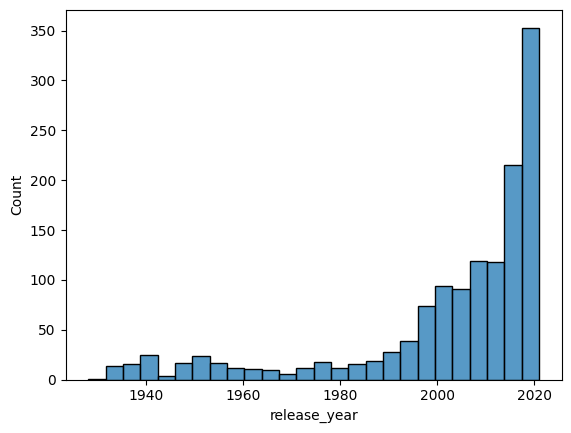

In [ ]:
ax = sns.histplot(x='release_year',data=df)

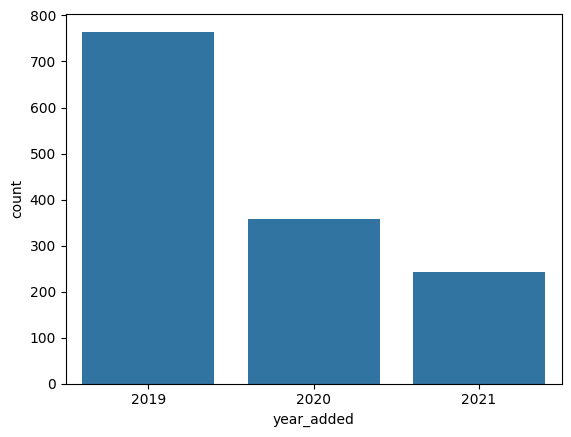

In [ ]:
ax =sns.countplot(x='year_added',data=df)

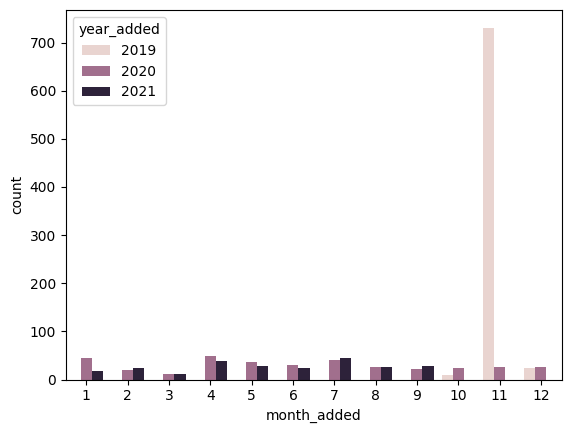

In [ ]:
#Disney+ lunched November 12,2019. They added many titles from the past at the first month.#
ax=sns.countplot(x='month_added',hue ="year_added",data=df)

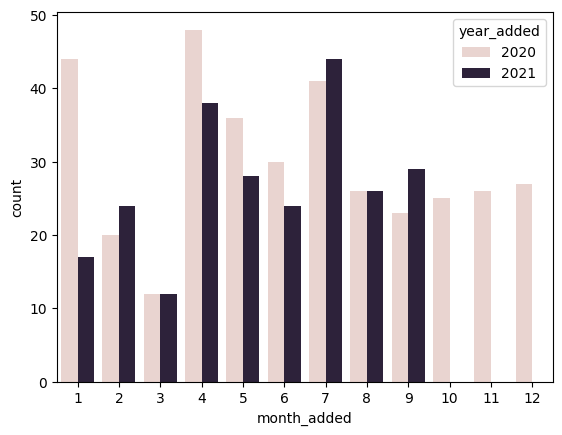

In [ ]:
#They add titles in a regular basis if filter the first month out.
df1 = df[df['year_added']>2019]
ax=sns.countplot(x='month_added',hue='year_added',data=df1)

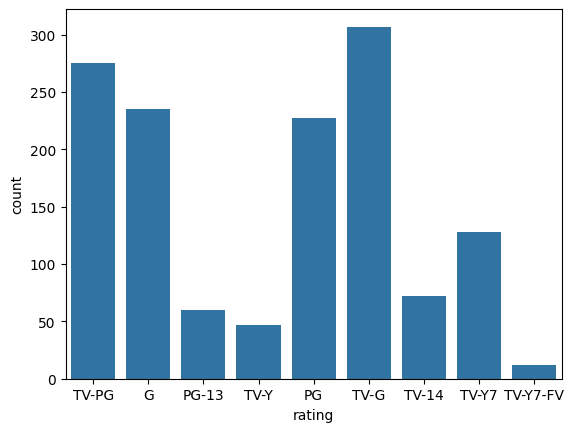

In [ ]:
ax = sns.countplot(x='rating',data=df)

In [ ]:
categories = df.value_counts(['listed_in']).head(10)
categories

,count
listed_in,
"Animation, Comedy, Family",120
"Action-Adventure, Animation, Comedy",75
"Action-Adventure, Animation, Kids",45
"Animals & Nature, Documentary, Family",40
"Action-Adventure, Animation, Family",40
"Animals & Nature, Docuseries, Family",38
"Animals & Nature, Documentary",34
"Action-Adventure, Comedy, Family",27
"Animation, Family, Fantasy",26


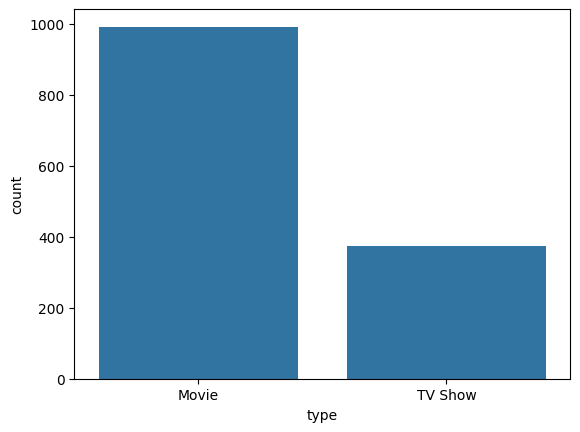

In [ ]:
ax = sns.countplot(x='type',data=df)

# Has Disney+ accelerated content acquisition over time?

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year

titles_added = df.groupby('year_added').size()

print(titles_added)

year_added
2019    765
2020    358
2021    242
dtype: int64


In [ ]:
df['content_age'] = 2021 - df['release_year']

In [ ]:
def categorize_content(age):

    if age <= 2:
        return 'New'

    elif age <= 10:
        return 'Recent'

    else:
        return 'Legacy'

df['content_segment'] = df['content_age'].apply(categorize_content)

In [ ]:
df['content_segment'].value_counts(normalize=True)*100

,proportion
content_segment,
Legacy,49.743590
Recent,29.157509
New,21.098901


# Insight
Nearly half of Disney+'s catalog consists of legacy content.

The platform heavily leverages its extensive intellectual property library, including classic Disney, Pixar, Marvel, and National Geographic content.

In [ ]:
monthly_additions = (
    df1.groupby(['year_added','month_added'])
    .size()
    .reset_index(name='titles_added')
)

monthly_additions

,year_added,month_added,titles_added
0,2020,1,44
1,2020,2,20
2,2020,3,12
3,2020,4,48
4,2020,5,36
5,2020,6,30
6,2020,7,41
7,2020,8,26
8,2020,9,23
9,2020,10,25


Does Disney+ follow seasonal content acquisition patterns to maximize subscriber growth?

In [ ]:
monthly_pct = (
    df1.groupby('month_added')
    .size()
    /
    len(df1)
    *100
)

monthly_pct

,0
month_added,
1,10.166667
2,7.333333
3,4.000000
4,14.333333
5,10.666667
6,9.000000
7,14.166667
8,8.666667
9,8.666667


# Insight
Disney+ follows a structured content scheduling strategy rather than random content uploads.
Content additions are concentrated around specific periods likely aligned with:
Summer vacations,
School holidays,
Family viewing periods.

# Audience Segmentation Analysis

<Axes: xlabel='rating', ylabel='count'>

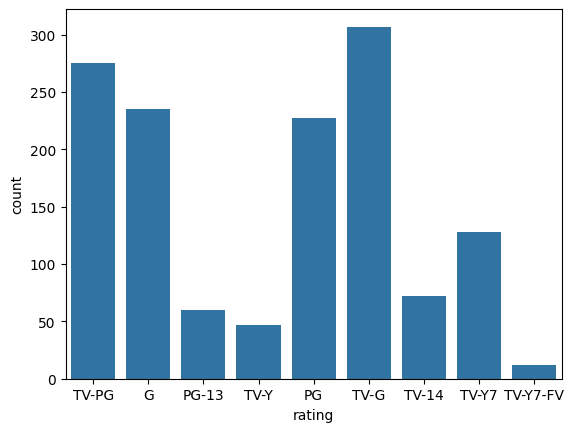

In [ ]:
sns.countplot(
    x='rating',
    data=df
)

In [ ]:
kids = ['TV-Y','TV-Y7','G']
family = ['TV-G','PG']
teen = ['TV-PG','PG-13']
adult = ['TV-14','R']

def audience_segment(rating):

    if rating in kids:
        return 'Kids'

    elif rating in family:
        return 'Family'

    elif rating in teen:
        return 'Teen'

    else:
        return 'Adult'

df['audience_segment'] = (
    df['rating']
    .apply(audience_segment)
)

<Axes: xlabel='audience_segment', ylabel='count'>

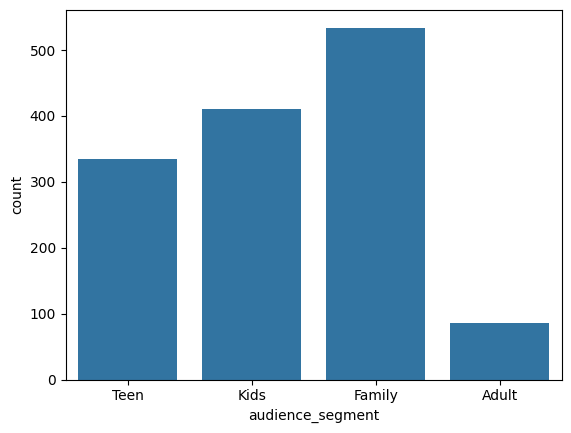

In [ ]:
sns.countplot(
    x='audience_segment',
    data=df
)

# Observation
The Family segment dominates the content catalog, followed by Kids and Teen content.

Adult-focused content represents only a small portion of the platform.

# Insight
Disney+ is strongly positioned as a family-centric streaming platform.

This content mix aligns with Disney's broader ecosystem:

Theme Parks,
Merchandise,
Franchises,
Family subscriptions.

# 1. How old is Disney's catalog?
# 2. How quickly does content reach Disney+?

<Axes: xlabel='content_age', ylabel='Count'>

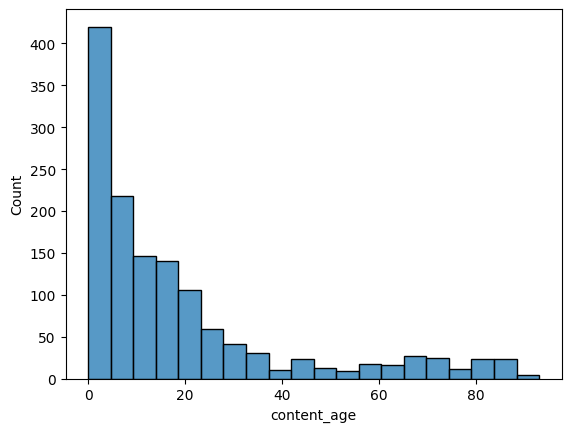

In [ ]:
df['content_age'] = (
    2021 - df['release_year']
)

sns.histplot(
    data=df,
    x='content_age',
    bins=20
)

# Observation

The content age distribution is heavily right-skewed.

Most content was released within the last 20 years, while a long tail of older titles extends back several decades.

# Insight

Disney+ successfully balances:

Evergreen classics and
Modern releases

<Axes: xlabel='release_lag', ylabel='Count'>

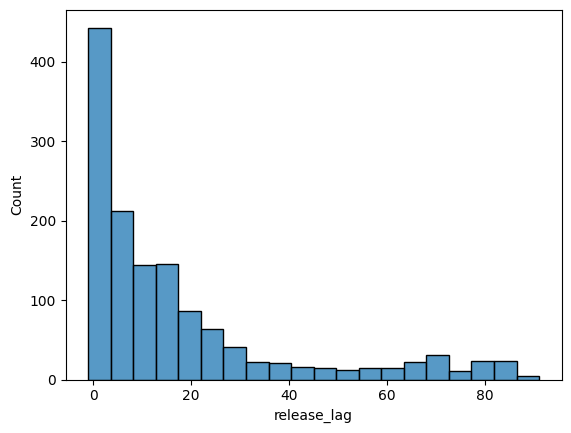

In [ ]:
df['release_lag'] = (
    df['year_added']
    - df['release_year']
)

sns.histplot(
    data=df,
    x='release_lag',
    bins=20
)

# Observation

Release lag distribution is concentrated near zero with a long tail.

Most content reaches Disney+ relatively quickly after release, while older titles are gradually introduced into the catalog.

# Insight

Disney+ combines two acquisition models:

Near-release additions for engagement and
historical catalog additions for library depth.

# Business Recommendations

## 1. Increase New Content Ratio

Current new-content share: 21.1%

Target: 30-35%

Expected Benefit:
* Higher subscriber acquisition

* Improved platform competitiveness



## 2. Expand International Content Partnerships

Potential expansion markets:
* India
* South Korea
* Japan

Expected Benefits:
* Regional subscriber growth
* Reduced geographic concentration risk


## 3. Maintain Family Content Leadership

Recommendation:

* Continue investing in family franchises.
* Expand multi-season family content.

Expected Benefits:

* Increased watch hours.
* Lower churn rates.

## 4. Optimize Seasonal Releases

Schedule premium content during:
* Summer periods
* Holiday periods
* Major school breaks

Expected Benefits:
* Higher engagement.
* Stronger retention.

"Due to the absence of user interaction data in the Disney+ catalog dataset, a synthetic user-rating environment was created using content preference simulation to prototype and evaluate collaborative filtering recommendation algorithms."

# Content-Based Recommender System

In [ ]:
# First Feature Engineering Step Create one metadata column

df['director'] = df['director'].fillna('')
df['cast'] = df['cast'].fillna('')
df['listed_in'] = df['listed_in'].fillna('')
df['description'] = df['description'].fillna('')
df['country'] = df['country'].fillna('')

df['metadata'] = (
    df['listed_in'] + ' ' +
    df['director'] + ' ' +
    df['cast'] + ' ' +
    df['country'] + ' ' +
    df['description']
)

In [ ]:
# Add More Useful Features
# Content Age
df['content_age'] = 2021 - df['release_year']

# Release Era
def era(year):

    if year < 1990:
        return 'Classic'

    elif year < 2010:
        return 'Modern'

    else:
        return 'Recent'

df['era'] = df['release_year'].apply(era)

# Genre Count
df['genre_count'] = (
    df['listed_in']
    .str.split(',')
    .apply(len)
)

# Cast count
df['cast_count'] = (
    df['cast']
    .str.split(',')
    .apply(len)
)

In [ ]:
df[['title',
    'metadata',
    'content_age',
    'era',
    'genre_count',
    'cast_count']].head()

,title,metadata,content_age,era,genre_count,cast_count
0,A Spark Story,"Documentary Jason Sterman, Leanne Dare Apthon ...",0,Recent,1,2
1,Spooky Buddies,"Comedy, Fantasy, Kids Robert Vince Tucker Albr...",10,Recent,3,6
2,The Fault in Our Stars,"Coming of Age, Drama, Romance Josh Boone Shail...",7,Recent,3,6
3,Dog: Impossible,"Animals & Nature, Docuseries, Family Matt Bei...",2,Recent,3,1
4,Spidey And His Amazing Friends,"Action-Adventure, Animation, Kids Benjamin Va...",0,Recent,3,5


## Stage 1 — TF-IDF Vectorization

In [ ]:
# Convert metadata text into numerical vectors that represent content characteristics.

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(
    df['metadata']
)

print(tfidf_matrix.shape)

(1365, 5000)


# Recommendation System Overview
To improve content discovery and user engagement, a collaborative filtering recommendation engine was developed using synthetic user-rating interactions generated from Disney+ content metadata. The system models user preferences and recommends similar titles based on historical rating behavior.

The recommendation pipeline includes:

* User preference simulation
* User–Item interaction matrix creation
* Pearson Correlation based item similarity
* Cosine Similarity and K-Nearest Neighbors (KNN)
* Hybrid recommendation architecture (future enhancement)

In [ ]:
df['movie_id'] = range(1, len(df)+1)

In [ ]:
df[['movie_id','title']].head()

,movie_id,title
0,1,A Spark Story
1,2,Spooky Buddies
2,3,The Fault in Our Stars
3,4,Dog: Impossible
4,5,Spidey And His Amazing Friends


In [ ]:
n_users = 1000

users = pd.DataFrame({
    'user_id': range(1, n_users+1)
})

In [ ]:
#Add User Demographics
np.random.seed(42)

users['gender'] = np.random.choice(
    ['M','F'],
    size=n_users
)

users['age_group'] = np.random.choice(
    ['Teen','Young Adult','Adult','Senior'],
    size=n_users,
    p=[0.2,0.4,0.3,0.1]
)

In [ ]:
#Each user should rate at least 20 movies.
ratings_list = []

for user in users['user_id']:

    watched_movies = np.random.choice(
        df['movie_id'],
        size=25,
        replace=False
    )

    for movie in watched_movies:

        rating = np.random.randint(1,6)

        ratings_list.append(
            [user,movie,rating]
        )

ratings = pd.DataFrame(
    ratings_list,
    columns=[
        'user_id',
        'movie_id',
        'rating'
    ]
)

In [ ]:
#Add Timestamps
ratings['timestamp'] = np.random.randint(
    1577836800,
    1640995200,
    size=len(ratings)
)

In [ ]:
cf_data = ratings.merge(
    df,
    on='movie_id',
    how='left'
)

In [ ]:
print(users.shape)
print(ratings.shape)
print(cf_data.shape)

cf_data.head()

(1000, 3)
(25000, 4)
(25000, 24)


,user_id,movie_id,rating_x,timestamp,show_id,type,title,director,cast,country,...,listed_in,description,year_added,month_added,min_duration,seasons,content_age,content_segment,audience_segment,release_lag
0,1,512,3,1604321799,s512,Movie,Pluto's Party,Milt Schaffer,"Jimmy MacDonald, Pinto Colvig",United States,...,"Animation, Family",It's Pluto's birthday party!,2020,4,8,None,69,Legacy,Family,68
1,1,52,5,1638754511,s52,Movie,Mrs. Doubtfire,Chris Columbus,"Robin Williams, Sally Field, Pierce Brosnan, H...",United States,...,"Comedy, Drama",An eccentric dad dresses as a British nanny so...,2021,8,126,None,28,Legacy,Teen,28
2,1,1172,5,1580903795,s1172,Movie,The African Lion,James Algar,Winston Hibler,United States,...,"Animals & Nature, Documentary, Family",Two wildlife experts spend years studying the ...,2019,11,72,None,66,Legacy,Kids,64
3,1,769,5,1578592449,s769,TV Show,Disney's Doug,NaN,"Connie Shulman, Doug Preis, Alice Playten, Chr...",United States,...,"Animation, Comedy, Coming of Age",Doug uses his imagination to navigate through ...,2019,11,None,3 Seasons,25,Legacy,Kids,23
4,1,558,2,1639405776,s558,Movie,The Lion King,Jon Favreau,"Donald Glover, Seth Rogen, Chiwetel Ejiofor, A...","United States, United Kingdom, South Africa",...,"Action-Adventure, Coming of Age, Drama",Disney’s The Lion King comes to life in a whol...,2020,1,125,None,2,New,Family,1


In [ ]:
# 1 Make Ratings Intelligent
genre_list = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

genre_list.head(20)

,count
listed_in,
Family,602
Animation,516
Comedy,495
Action-Adventure,436
Animals & Nature,199
Coming of Age,198
Fantasy,180
Documentary,167
Kids,136


In [ ]:
# 2 Create User Preference Profiles
favorite_genres = [
    'Animation',
    'Family',
    'Comedy',
    'Action-Adventure',
    'Drama',
    'Documentary',
    'Animals & Nature'
]

users['favorite_genre'] = np.random.choice(
    favorite_genres,
    size=len(users)
)
users.head()

,user_id,gender,age_group,favorite_genre
0,1,M,Adult,Animation
1,2,F,Young Adult,Animation
2,3,M,Young Adult,Drama
3,4,M,Adult,Drama
4,5,M,Adult,Documentary


In [ ]:
# 3: Rebuild Ratings
ratings_list = []

for _, user in users.iterrows():

    user_id = user['user_id']

    fav_genre = user['favorite_genre']

    watched_movies = np.random.choice(
        df['movie_id'],
        size=25,
        replace=False
    )

    for movie in watched_movies:

        movie_genres = str(
            df.loc[
                df['movie_id']==movie,
                'listed_in'
            ].values[0]
        )

        if fav_genre in movie_genres:

            rating = np.random.choice(
                [4,5],
                p=[0.4,0.6]
            )

        else:

            rating = np.random.choice(
                [1,2,3,4],
                p=[0.2,0.3,0.3,0.2]
            )

        ratings_list.append(
            [user_id,movie,rating]
        )

ratings = pd.DataFrame(
    ratings_list,
    columns=[
        'user_id',
        'movie_id',
        'rating'
    ]
)

In [ ]:
# 4: Create Movie-User Matrix
movie_matrix = ratings.pivot_table(
    index='movie_id',
    columns='user_id',
    values='rating'
)

movie_matrix.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
movie_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
user_matrix = ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)

user_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1356,1357,1358,1359,1360,1361,1362,1363,1364,1365
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
movie_matrix_filled = movie_matrix.fillna(0)

user_matrix_filled = user_matrix.fillna(0)

# 1. Pearson Correlation Recommender

In [ ]:
# create movie lookup
movie_lookup = df[
    ['movie_id','title']
]
# function:
def pearson_recommend(movie_name,
                      top_n=5):

    movie_id = df[
        df['title']==movie_name
    ]['movie_id'].iloc[0]

    target = movie_matrix.loc[movie_id]

    correlations = movie_matrix.T.corrwith(
        target,
        method='pearson'
    )
    correlations = correlations.dropna()

    corr_df = pd.DataFrame(
        correlations,
        columns=['correlation']
    )

    corr_df = corr_df.dropna()

    corr_df = corr_df.sort_values(
        'correlation',
        ascending=False
    )

    similar_ids = corr_df.index[1:top_n+1]

    return df[
        df['movie_id'].isin(
            similar_ids
        )
    ][['title','listed_in']]

In [ ]:
pearson_recommend(
    "The Lion King"
)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,title,listed_in
253,"Miraculous World: New York, United Heroez","Action-Adventure, Animation, Fantasy"
499,Double Dribble,"Animation, Family, Sports"
813,Ferdinand the Bull,"Animation, Comedy, Family"
965,Marvel Studios' Avengers: Endgame,"Action-Adventure, Fantasy, Science Fiction"
1304,Toy Story 2,"Action-Adventure, Animation, Comedy"


# Cosine Similarity Matrix

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(
    movie_matrix_filled
)

In [ ]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=movie_matrix_filled.index,
    columns=movie_matrix_filled.index
)

# 2. KNN Recommender

In [ ]:
from sklearn.neighbors import NearestNeighbors
knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn.fit(movie_matrix_filled)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
def knn_recommend(movie_name):

    movie_id = df[
        df['title']==movie_name
    ]['movie_id'].iloc[0]

    movie_idx = (
        movie_matrix_filled
        .index
        .get_loc(movie_id)
    )

    distances, indices = knn.kneighbors(
        movie_matrix_filled.iloc[
            movie_idx
        ].values.reshape(1,-1),
        n_neighbors=6
    )

    recommendations = []

    for idx in indices.flatten()[1:]:

        recommendations.append(
            df.loc[
                df['movie_id']==
                movie_matrix_filled.index[idx],
                'title'
            ].values[0]
        )

    return recommendations

In [ ]:
knn_recommend(
    "The Lion King"
)

['High School Musical: The Musical: The Series',
 'Geek Charming',
 'You Wish!',
 'The Old Mill',
 'Meet The Chimps']

In [ ]:
ratings['rating'].value_counts()

,count
rating,
4,6319
3,5611
2,5572
5,3891
1,3607


In [ ]:
movie_matrix.shape

(1365, 1000)

In [ ]:
user_matrix.shape

(1000, 1365)

In [ ]:
print(f"Users: {ratings['user_id'].nunique()}")
print(f"Movies: {ratings['movie_id'].nunique()}")
print(f"Ratings: {len(ratings)}")

sparsity = (
    1 -
    len(ratings) /
    (
        ratings['user_id'].nunique()
        *
        ratings['movie_id'].nunique()
    )
) * 100

print(f"Sparsity: {sparsity:.2f}%")

Users: 1000
Movies: 1365
Ratings: 25000
Sparsity: 98.17%


The interaction matrix exhibits high sparsity, a common challenge in recommendation systems, making similarity-based approaches appropriate for personalized recommendations.

# Business Value

The recommendation engine addresses a critical challenge for streaming platforms: content discovery.

Expected benefits include:

* Reduced search friction for users
* Improved content visibility across the catalog
* Increased watch-time and session duration
* Better utilization of long-tail content
* Enhanced user retention through personalization

In [ ]:
knn_recommend(
    "Spidey And His Amazing Friends"
)

['Mickey Mouse Mixed-Up Adventures',
 'Auntie Edna',
 "Fantastic Four: World's Greatest Heroes",
 'Pocahontas',
 'Holes']